✅ Dataset loaded successfully
✅ Preprocessing complete. Dataset shape: (260, 3)
📊 Train size: 208, Test size: 52

🚀 BASELINE TBATS TIME SERIES FORECASTING MODEL

🟣 BASELINE TBATS MODEL

🔄 Training TBATS model... (this may take a while)

📌 Parameters:
   Use Trend: True
   Use Damped Trend: False
   Use Box-Cox: False
   Seasonal Periods: [7]

📊 Performance Metrics:
   MAE: 108.5113
   MSE: 16221.3408
   RMSE: 127.3630
   MAPE: 52.5413
   sMAPE: 76.2361
   MASE: 5.0127
   R²: -2.7965
   AIC: 2517.9522
   BIC: nan
   Execution_Time: 16.9963


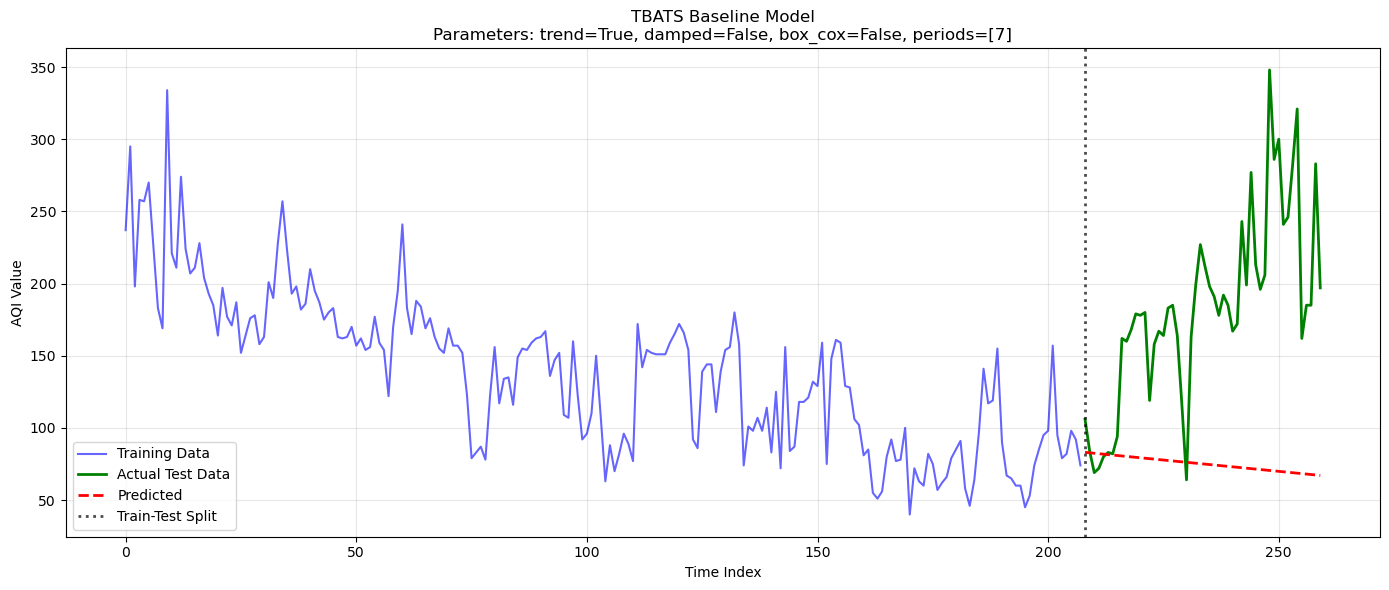

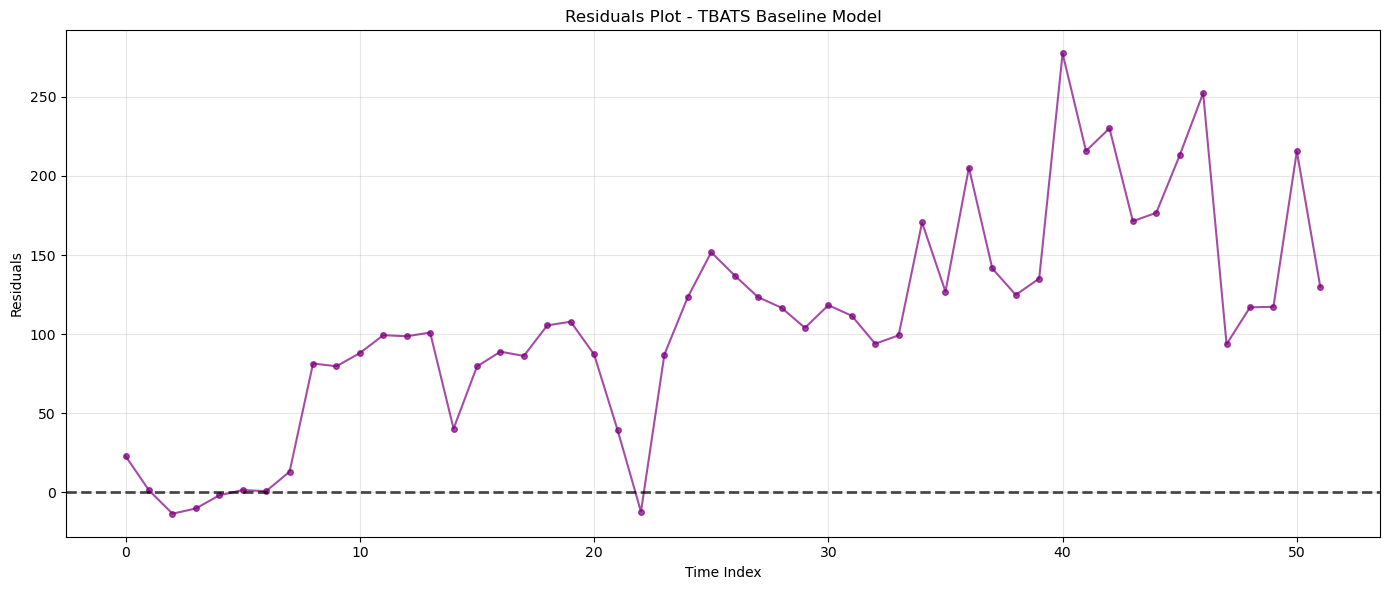


📋 TBATS BASELINE MODEL SUMMARY

 Model                                           Parameters       RMSE        MAE      MAPE     sMAPE     MASE       R²         AIC  BIC  Time (s)
TBATS trend=True, damped=False, box_cox=False, periods=[7] 127.363027 108.511295 52.541345 76.236115 5.012684 -2.79648 2517.952237  NaN 16.996299

✅ Results saved to 'baseline_tbats_results.csv'
✅ Predictions saved to 'baseline_tbats_predictions.csv'

✅ BASELINE TBATS FORECASTING COMPLETE


In [1]:
"""
Baseline TBATS Time Series Forecasting Model
With Standard Parameters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tbats import TBATS
import warnings
warnings.filterwarnings('ignore')

# ================== DATA LOADING ==================
file_path = "D:\\New folder\\Rampal-AQI.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully")
except FileNotFoundError:
    print(f"❌ File not found at: {file_path}")
    exit()

# ================== PREPROCESSING ==================
def format_date(date_str):
    """Format date to MM/DD/YYYY"""
    parts = date_str.split('/')
    month = parts[0].zfill(2)
    day = parts[1].zfill(2)
    year = parts[2]
    return f"{month}/{day}/{year}"

# Apply date formatting
df['Date'] = df['Date'].apply(format_date)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Sort by date
df = df.sort_values(by='Date')

# Remove DNA values
df = df[df['AQI'] != 'DNA']
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')
df = df.dropna(subset=['AQI'])

print(f"✅ Preprocessing complete. Dataset shape: {df.shape}")

# ================== TRAIN-TEST SPLIT ==================
train_size = int(len(df) * 0.8)
train_df = df[:train_size]
test_df = df[train_size:]

y_train = train_df['AQI'].values
y_test = test_df['AQI'].values

print(f"📊 Train size: {len(y_train)}, Test size: {len(y_test)}")

# ================== METRICS CALCULATION ==================
def calculate_metrics(y_true, y_pred, y_train, exec_time, aic=None, bic=None):
    """Calculate comprehensive evaluation metrics"""
    
    # Basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # sMAPE (Symmetric MAPE)
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100
    
    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(y_train, 1)[1:]
    mae_naive = np.mean(np.abs(y_train[1:] - naive_forecast))
    mase = mae / (mae_naive + 1e-10)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'sMAPE': smape,
        'MASE': mase,
        'R²': r2,
        'AIC': aic if aic is not None else np.nan,
        'BIC': bic if bic is not None else np.nan,
        'Execution_Time': exec_time
    }

# ================== VISUALIZATION FUNCTIONS ==================
def plot_predictions(y_train, y_test, y_pred, model_name, params_str):
    """Plot training data and predictions with train-test split line"""
    plt.figure(figsize=(14, 6))
    
    # Plot training data
    plt.plot(range(len(y_train)), y_train, label='Training Data', color='blue', alpha=0.6)
    
    # Plot test data
    test_start = len(y_train)
    plt.plot(range(test_start, test_start + len(y_test)), y_test,
             label='Actual Test Data', color='green', linewidth=2)
    
    # Plot predictions
    plt.plot(range(test_start, test_start + len(y_pred)), y_pred,
             label='Predicted', color='red', linestyle='--', linewidth=2)
    
    # Add vertical line for train-test split
    plt.axvline(x=test_start, color='black', linestyle=':', linewidth=2, 
                label='Train-Test Split', alpha=0.7)
    
    plt.title(f'{model_name} Baseline Model\nParameters: {params_str}')
    plt.xlabel('Time Index')
    plt.ylabel('AQI Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_test, y_pred, model_name):
    """Plot residuals"""
    plt.figure(figsize=(14, 6))
    
    residuals = y_test - y_pred
    plt.plot(range(len(residuals)), residuals, color='purple', marker='o', 
             markersize=4, linestyle='-', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.title(f'Residuals Plot - {model_name} Baseline Model')
    plt.xlabel('Time Index')
    plt.ylabel('Residuals')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ================== BASELINE TBATS MODEL ==================
def baseline_tbats(y_train, y_test):
    """
    Baseline TBATS Model with standard parameters
    - use_trend: True
    - use_damped_trend: False
    - use_box_cox: False
    - seasonal_periods: [7] (weekly seasonality)
    """
    print("\n" + "="*60)
    print("🟣 BASELINE TBATS MODEL")
    print("="*60)
    
    # Baseline parameters
    use_trend = True
    use_damped_trend = False
    use_box_cox = False
    seasonal_periods = [7]  # Weekly seasonality
    
    start_time = time.time()
    
    try:
        # Create TBATS estimator with baseline parameters
        tbats_estimator = TBATS(
            use_trend=use_trend,
            use_damped_trend=use_damped_trend,
            use_box_cox=use_box_cox,
            seasonal_periods=seasonal_periods
        )
        
        print("\n🔄 Training TBATS model... (this may take a while)")
        
        # Fit TBATS model
        model_fit = tbats_estimator.fit(y_train)
        
        # Make predictions
        y_pred = model_fit.forecast(steps=len(y_test))
        
        execution_time = time.time() - start_time
        
        # Get AIC and BIC (if available)
        try:
            aic = model_fit.aic
        except:
            aic = None
        
        try:
            bic = np.nan  # TBATS doesn't provide BIC directly
        except:
            bic = None
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred, y_train, execution_time, aic, bic)
        
        # Print results
        print(f"\n📌 Parameters:")
        print(f"   Use Trend: {use_trend}")
        print(f"   Use Damped Trend: {use_damped_trend}")
        print(f"   Use Box-Cox: {use_box_cox}")
        print(f"   Seasonal Periods: {seasonal_periods}")
        
        print(f"\n📊 Performance Metrics:")
        for metric, value in metrics.items():
            print(f"   {metric}: {value:.4f}")
        
        # Plot predictions
        params_str = f"trend={use_trend}, damped={use_damped_trend}, box_cox={use_box_cox}, periods={seasonal_periods}"
        plot_predictions(y_train, y_test, y_pred, "TBATS", params_str)
        
        # Plot residuals
        plot_residuals(y_test, y_pred, "TBATS")
        
        return {
            'model': 'TBATS',
            'params': params_str,
            'predictions': y_pred,
            'metrics': metrics,
            'model_fit': model_fit
        }
        
    except Exception as e:
        print(f"❌ Error in TBATS model: {str(e)}")
        return None

# ================== MAIN EXECUTION ==================
if __name__ == "__main__":
    
    print("\n" + "="*60)
    print("🚀 BASELINE TBATS TIME SERIES FORECASTING MODEL")
    print("="*60)
    
    # Run TBATS baseline
    tbats_result = baseline_tbats(y_train, y_test)
    
    # ================== RESULTS SUMMARY ==================
    if tbats_result:
        print("\n" + "="*60)
        print("📋 TBATS BASELINE MODEL SUMMARY")
        print("="*60)
        
        summary_df = pd.DataFrame([{
            'Model': tbats_result['model'],
            'Parameters': tbats_result['params'],
            'RMSE': tbats_result['metrics']['RMSE'],
            'MAE': tbats_result['metrics']['MAE'],
            'MAPE': tbats_result['metrics']['MAPE'],
            'sMAPE': tbats_result['metrics']['sMAPE'],
            'MASE': tbats_result['metrics']['MASE'],
            'R²': tbats_result['metrics']['R²'],
            'AIC': tbats_result['metrics']['AIC'],
            'BIC': tbats_result['metrics']['BIC'],
            'Time (s)': tbats_result['metrics']['Execution_Time']
        }])
        
        print("\n", summary_df.to_string(index=False))
        
        # ================== SAVE RESULTS ==================
        summary_df.to_csv('baseline_tbats_results.csv', index=False)
        print("\n✅ Results saved to 'baseline_tbats_results.csv'")
        
        # Save predictions
        predictions_df = pd.DataFrame({
            'Actual': y_test,
            'Predicted': tbats_result['predictions'],
            'Residuals': y_test - tbats_result['predictions']
        })
        predictions_df.to_csv('baseline_tbats_predictions.csv', index=False)
        print("✅ Predictions saved to 'baseline_tbats_predictions.csv'")
        
    else:
        print("\n❌ TBATS model failed to complete")
    
    print("\n" + "="*60)
    print("✅ BASELINE TBATS FORECASTING COMPLETE")
    print("="*60)

✅ TBATS imported successfully!
✅ Dataset loaded successfully
✅ Preprocessing complete. Dataset shape: (260, 3)

PROCESSING: RAMPAL AQI DATA
Training set: 208 samples
Test set: 52 samples
Running Grid Search...
Total combinations to test: 32
Progress: 5/32 combinations tested...
Progress: 15/32 combinations tested...
Progress: 20/32 combinations tested...
Progress: 25/32 combinations tested...

🏆 BEST PARAMETERS: {'seasonal_periods': [30], 'use_box_cox': False, 'use_damped_trend': False, 'use_trend': False}

📈 PERFORMANCE METRICS:
   MAE: 96.7682
   MSE: 12581.6878
   RMSE: 112.1681
   MAPE: 49.3810
   sMAPE: 65.4575
   MASE: 4.4702
   R²: -1.9446
   AIC: nan
   BIC: nan
   Execution_Time: 469.3231


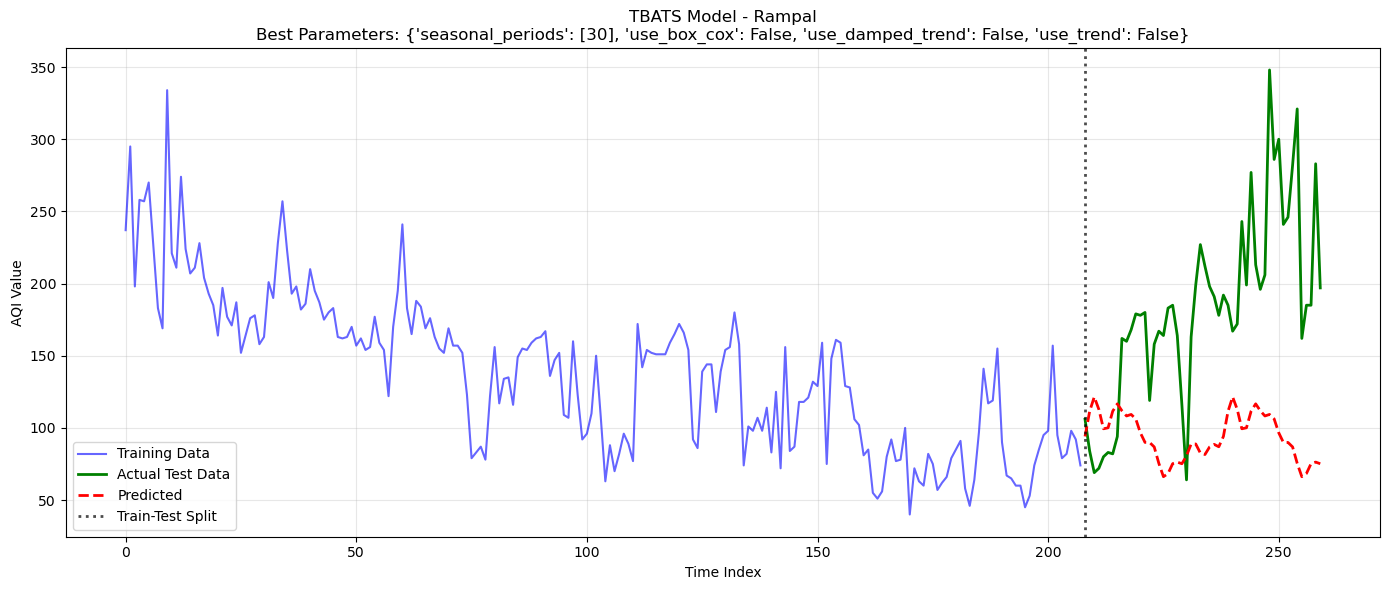

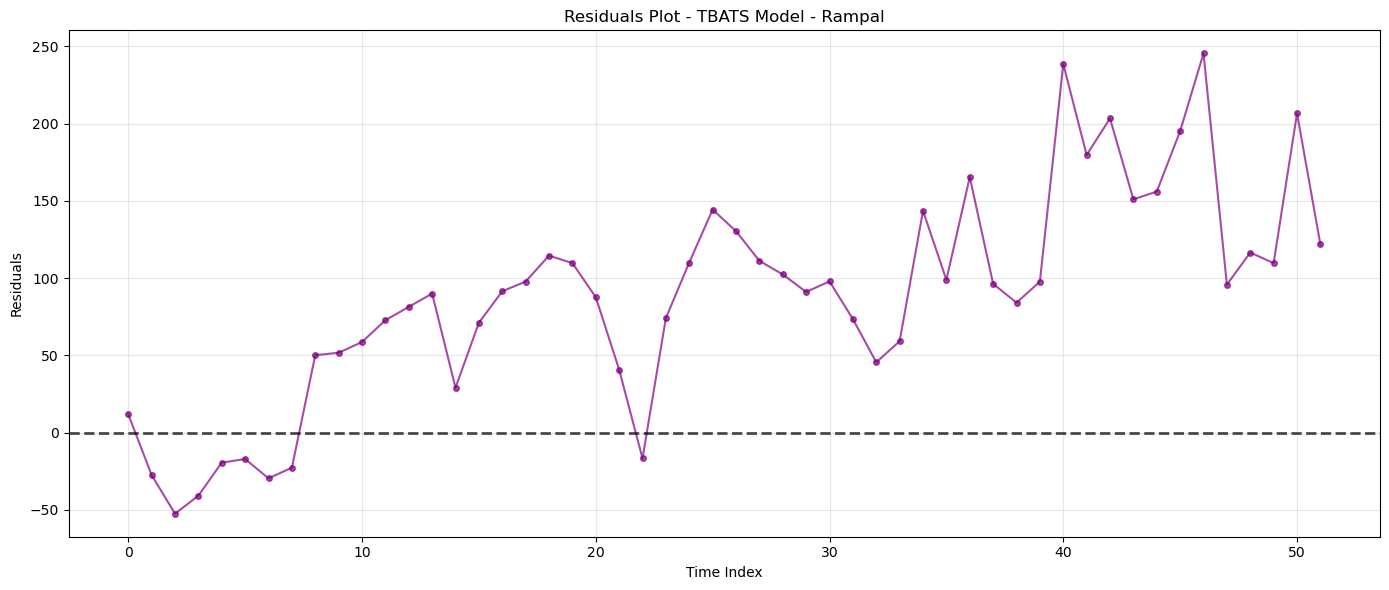

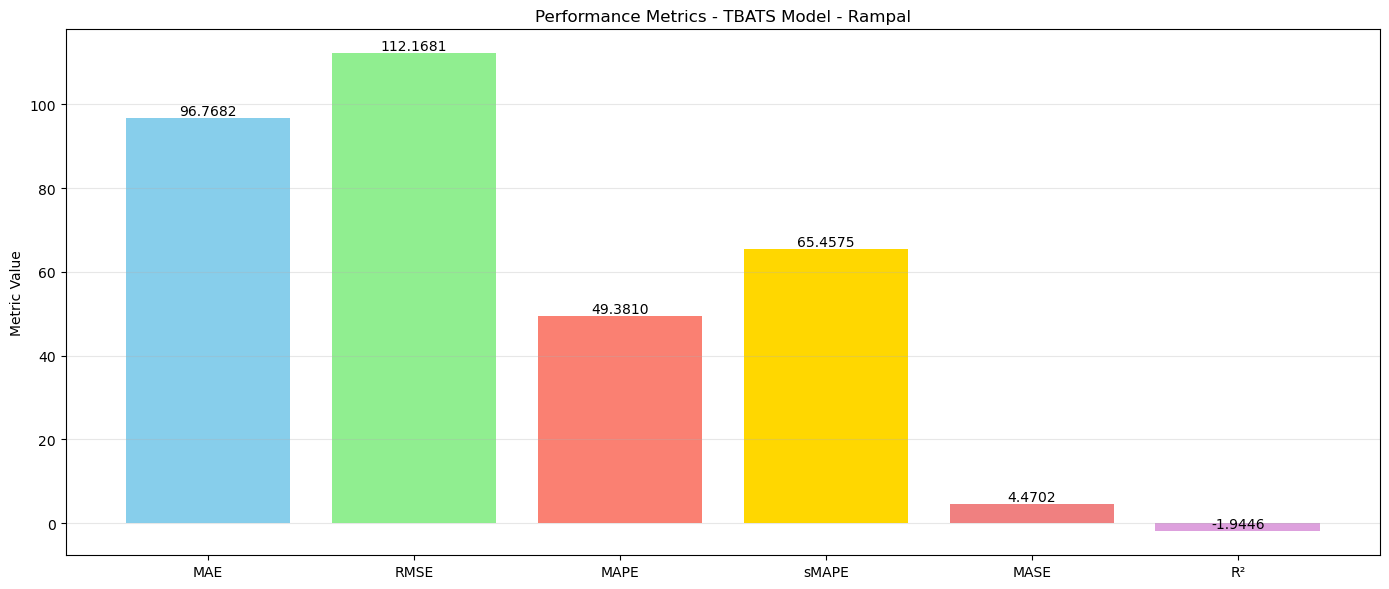


🎉 TBATS PROCESSING COMPLETED


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid
import time
import warnings
warnings.filterwarnings('ignore')

# Try importing TBATS with error handling
try:
    from tbats import TBATS
    print("✅ TBATS imported successfully!")
except ImportError as e:
    print(f"❌ Error importing TBATS: {e}")
    print("\nPlease run: !pip install tbats")
    exit()

# ================== DATA LOADING ==================
file_path = "D:\\New folder\\Rampal-AQI.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully")
except FileNotFoundError:
    print(f"❌ File not found at: {file_path}")
    exit()

# ================== PREPROCESSING ==================
def format_date(date_str):
    """Format date to MM/DD/YYYY"""
    parts = date_str.split('/')
    month = parts[0].zfill(2)
    day = parts[1].zfill(2)
    year = parts[2]
    return f"{month}/{day}/{year}"

# Apply date formatting
df['Date'] = df['Date'].apply(format_date)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Sort by date
df = df.sort_values(by='Date')

# Remove DNA values
df = df[df['AQI'] != 'DNA']
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')
df = df.dropna(subset=['AQI'])

print(f"✅ Preprocessing complete. Dataset shape: {df.shape}")

# ================== METRICS CALCULATION ==================
def calculate_metrics(y_true, y_pred, y_train, exec_time, aic=None, bic=None):
    """Calculate comprehensive evaluation metrics"""
    
    # Basic metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    # sMAPE (Symmetric MAPE)
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100
    
    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(y_train, 1)[1:]
    mae_naive = np.mean(np.abs(y_train[1:] - naive_forecast))
    mase = mae / (mae_naive + 1e-10)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'sMAPE': smape,
        'MASE': mase,
        'R²': r2,
        'AIC': aic if aic is not None else np.nan,
        'BIC': bic if bic is not None else np.nan,
        'Execution_Time': exec_time
    }

# ================== VISUALIZATION ==================
def plot_predictions(y_train, y_test, y_pred, city_name, best_params):
    """Plot training data and predictions with train-test split line"""
    plt.figure(figsize=(14, 6))
    
    # Plot training data
    plt.plot(range(len(y_train)), y_train, label='Training Data', color='blue', alpha=0.6)
    
    # Plot test data
    test_start = len(y_train)
    plt.plot(range(test_start, test_start + len(y_test)), y_test,
             label='Actual Test Data', color='green', linewidth=2)
    
    # Plot predictions
    plt.plot(range(test_start, test_start + len(y_pred)), y_pred,
             label='Predicted', color='red', linestyle='--', linewidth=2)
    
    # Add vertical line for train-test split
    plt.axvline(x=test_start, color='black', linestyle=':', linewidth=2, 
                label='Train-Test Split', alpha=0.7)
    
    plt.title(f'TBATS Model - {city_name}\nBest Parameters: {best_params}')
    plt.xlabel('Time Index')
    plt.ylabel('AQI Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residuals(y_test, y_pred, city_name):
    """Plot residuals"""
    plt.figure(figsize=(14, 6))
    
    residuals = y_test - y_pred
    plt.plot(range(len(residuals)), residuals, color='purple', marker='o', 
             markersize=4, linestyle='-', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.title(f'Residuals Plot - TBATS Model - {city_name}')
    plt.xlabel('Time Index')
    plt.ylabel('Residuals')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_metrics(metrics, city_name):
    """Plot performance metrics"""
    plt.figure(figsize=(14, 6))
    
    metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE', 'R²']
    values = [metrics[m] for m in metrics_to_plot]
    
    bars = plt.bar(metrics_to_plot, values, 
                   color=['skyblue', 'lightgreen', 'salmon', 'gold', 'lightcoral', 'plum'])
    
    plt.title(f'Performance Metrics - TBATS Model - {city_name}')
    plt.ylabel('Metric Value')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# ================== TBATS MODEL WITH GRIDSEARCH ==================
def tbats_grid_search(y_train, y_test):
    """TBATS Grid Search using ParameterGrid"""
    
    # Define parameter grid
    param_grid = {
        'use_trend': [True, False],
        'use_damped_trend': [True, False],
        'use_box_cox': [True, False],
        'seasonal_periods': [[7], [30], [7, 30], None]
    }
    
    grid = ParameterGrid(param_grid)
    best_score = float('inf')
    best_params = None
    best_model = None
    
    print(f"Total combinations to test: {len(grid)}")
    
    start_time = time.time()
    
    for i, params in enumerate(grid, 1):
        try:
            # Skip invalid combinations
            if params['use_damped_trend'] and not params['use_trend']:
                continue
            
            tbats_estimator = TBATS(
                use_trend=params['use_trend'],
                use_damped_trend=params['use_damped_trend'],
                use_box_cox=params['use_box_cox'],
                seasonal_periods=params['seasonal_periods']
            )
            
            model = tbats_estimator.fit(y_train)
            
            # Make predictions
            y_pred = model.forecast(steps=len(y_test))
            
            # Calculate RMSE
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            if rmse < best_score:
                best_score = rmse
                best_params = params
                best_model = model
            
            if i % 5 == 0:
                print(f"Progress: {i}/{len(grid)} combinations tested...")
                
        except:
            continue
    
    execution_time = time.time() - start_time
    
    return best_params, best_model, execution_time

# ================== MAIN EXECUTION ==================
try:
    print(f"\n{'='*70}")
    print(f"PROCESSING: RAMPAL AQI DATA")
    print(f"{'='*70}")
    
    # Prepare data
    if df.empty or len(df) < 100:
        print(f"❌ Insufficient data: {len(df)} samples")
        exit()
    
    df_clean = df.copy()
    df_clean.set_index('Date', inplace=True)
    df_clean.sort_index(inplace=True)
    
    # 80-20 split
    split_idx = int(len(df_clean) * 0.8)
    train_data = df_clean.iloc[:split_idx]
    test_data = df_clean.iloc[split_idx:]
    
    y_train = train_data['AQI'].values
    y_test = test_data['AQI'].values
    
    print(f"Training set: {len(y_train)} samples")
    print(f"Test set: {len(y_test)} samples")
    
    # Grid Search
    print("Running Grid Search...")
    best_params, best_model, exec_time = tbats_grid_search(y_train, y_test)
    
    if best_model is None:
        print(f"❌ No successful model found")
        exit()
    
    # Make predictions
    y_pred = best_model.forecast(steps=len(y_test))
    
    # Calculate metrics
    metrics = calculate_metrics(y_test, y_pred, y_train, exec_time)
    
    # Display results
    print(f"\n🏆 BEST PARAMETERS: {best_params}")
    print("\n📈 PERFORMANCE METRICS:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")
    
    # Visualizations
    plot_predictions(y_train, y_test, y_pred, "Rampal", best_params)
    plot_residuals(y_test, y_pred, "Rampal")
    plot_metrics(metrics, "Rampal")
    
except Exception as e:
    print(f"❌ Error processing data: {e}")

print(f"\n{'='*70}")
print("🎉 TBATS PROCESSING COMPLETED")
print(f"{'='*70}")